Tutorial: https://youtu.be/ORyfPJypKuU?si=D0J8witReagVns1q

In [550]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression

In [551]:
X,y = make_regression(n_samples=4,n_features=1,n_informative=1, n_targets=1, noise = 80, random_state=13)

In [552]:
import matplotlib.pyplot as plt

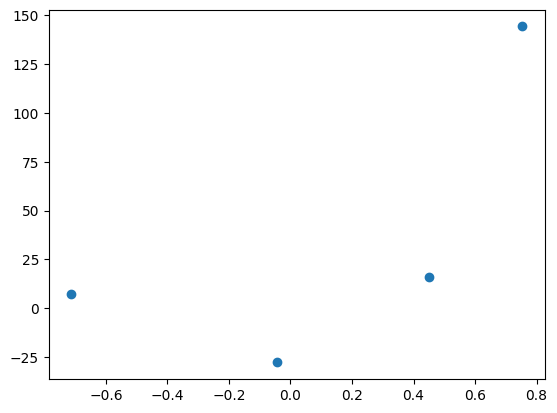

In [553]:
plt.scatter(X,y)

In [554]:
from sklearn.linear_model import LinearRegression

In [555]:
lr = LinearRegression()

In [556]:
lr.fit(X,y)

LinearRegression()

In [557]:
print(lr.intercept_)
print(lr.coef_)

26.15963284313262
[78.35063668]


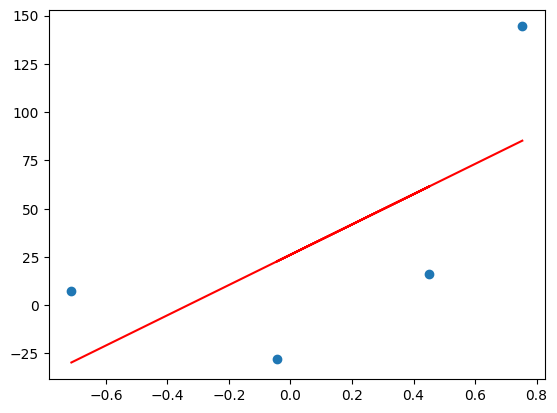

In [558]:
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red')

In [559]:
lr.predict(X)

array([-29.65662909,  61.55941724,  22.67278832,  85.21770852])

In [560]:
## We will apply Gradient Descent assuming m=78.35 while b=0
y_pred = ((78.35 * X) + 0).reshape(4)

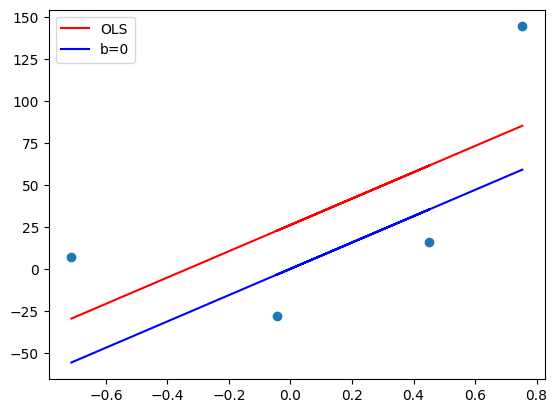

In [561]:
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red',label="OLS")
plt.plot(X,y_pred,color='blue',label="b=0")
plt.legend()

In [562]:
m = 78.34
b = 0

loss_slope = -2 * np.sum(y - m*X.ravel() - b)  # (derivative of loss func)
loss_slope

np.float64(-209.2866077816325)

In [563]:
# lets take learning rate =0.1
lrate = 0.1

step_size = loss_slope*lrate
step_size

np.float64(-20.928660778163252)

In [564]:
## calculating the new intercept
b = b - step_size
b

np.float64(20.928660778163252)

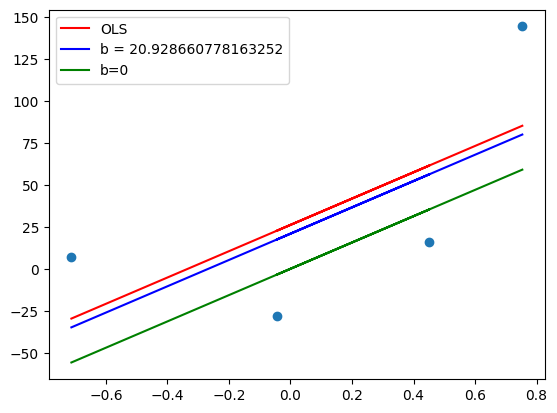

In [565]:
y_pred1 = ((78.35 * X) + b).reshape(4)
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red',label="OLS")
plt.plot(X,y_pred1,color='blue',label="b = {}".format(b))
plt.plot(X,y_pred,color='green',label="b=0")
plt.legend()

In [566]:
## iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-41.85732155632651)

In [567]:
stepsize= loss_slope*lrate
stepsize

np.float64(-4.185732155632651)

In [568]:
b = b - stepsize
b

np.float64(25.114392933795905)

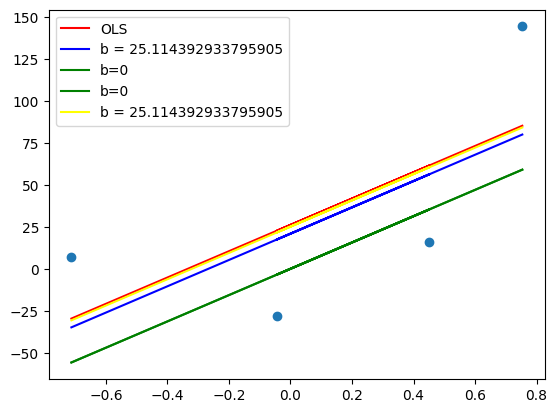

In [569]:
y_pred2 = ((78.35 * X) + b).reshape(4)
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red',label="OLS")
plt.plot(X,y_pred1,color='blue',label="b = {}".format(b))
plt.plot(X,y_pred,color='green',label="b=0")
plt.plot(X,y_pred,color='green',label="b=0")
plt.plot(X,y_pred2,color='yellow',label="b = {}".format(b))

plt.legend()

In [570]:
## Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-8.371464311265257)

In [571]:
stepsize= loss_slope*lrate
stepsize

np.float64(-0.8371464311265258)

In [572]:
b = b - stepsize
b

np.float64(25.951539364922432)

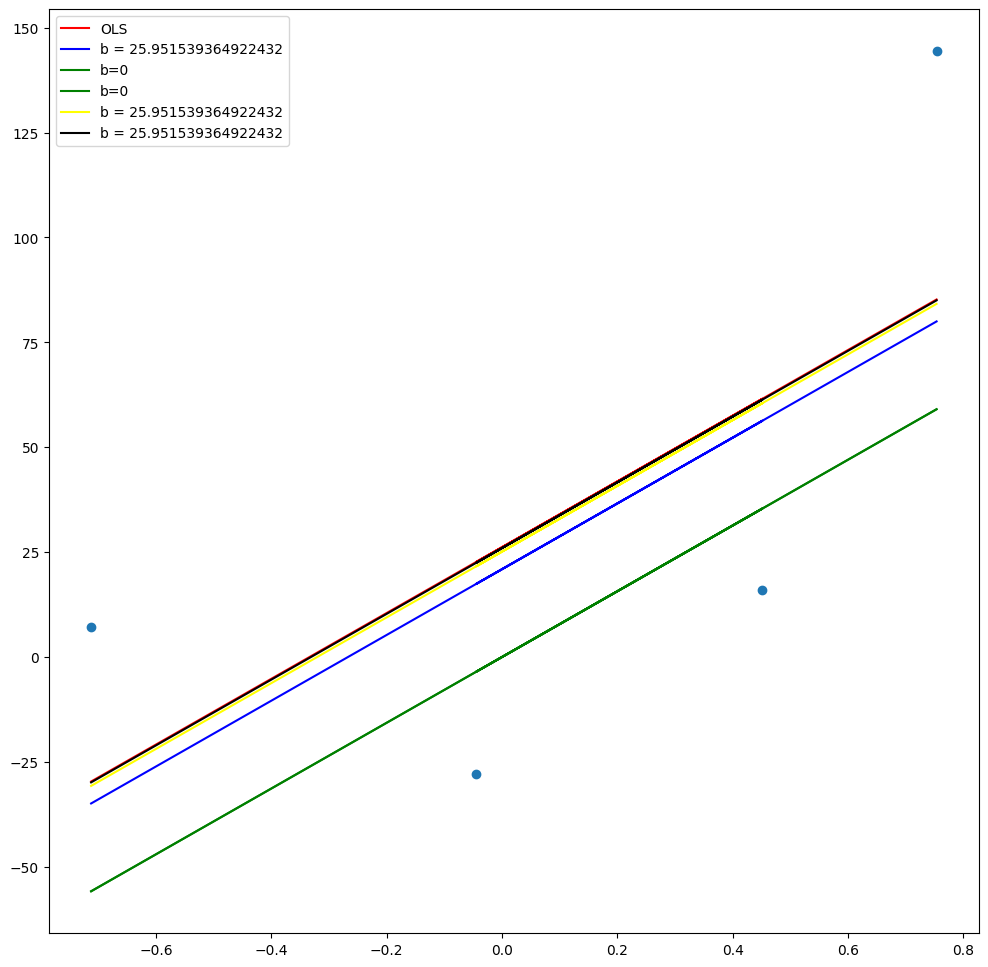

In [573]:
plt.figure(figsize=(12,12))
y_pred3 = ((78.35 * X) + b).reshape(4)
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red',label="OLS")
plt.plot(X,y_pred1,color='blue',label="b = {}".format(b))
plt.plot(X,y_pred,color='green',label="b=0")
plt.plot(X,y_pred,color='green',label="b=0")
plt.plot(X,y_pred2,color='yellow',label="b = {}".format(b))
plt.plot(X,y_pred3,color='black',label="b = {}".format(b))


plt.legend()

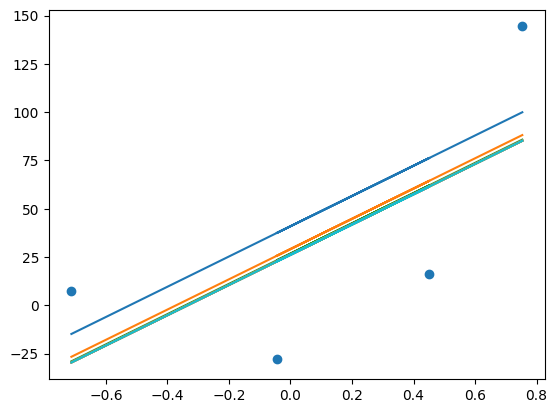

In [574]:
lr = 0.1
m = 78.3
b = 100

epochs = 10

for i in range(epochs):
  loss_slope = - 2 * np.sum(y- m*X.ravel() - b)
  b = b - (lr * loss_slope)
  y_pred = m * X + b

  plt.plot(X,y_pred)
plt.scatter(X,y)

## Gradient Descent Implementation (b only)

In [575]:
from sklearn.datasets import make_classification
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [576]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,noise=20,n_targets=1)

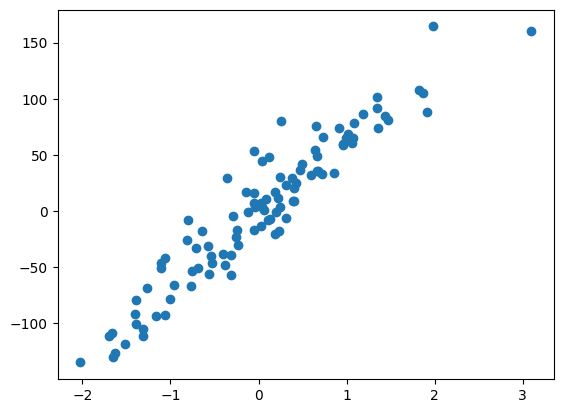

In [577]:
plt.scatter(X,y)

In [578]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lr = LinearRegression()

In [579]:
lr.fit(X,y)

LinearRegression()

In [580]:
np.mean(cross_val_score(lr,X,y,cv=10,scoring="r2"))

np.float64(0.8589207957313325)

In [581]:
y_pred = lr.predict(X_test)

In [582]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.8827570137975181


In [583]:
print(lr.coef_)
print(lr.intercept_)

[63.85787605]
-0.18763534955397643


In [584]:
m=65.4

In [599]:
class GDRegressor:
  def __init__(self,learning_rate,epochs):
    self.m = 100
    self.lr = learning_rate
    self.epochs = epochs
    self.b=-120

  def fit(self,X,y):
    #calculate b using GD
    for i in range(self.epochs):
      loss_slope_b = - 2 * np.sum(y- self.m*X.ravel() - self.b)
      loss_slope_m = - 2 * np.sum((y- self.m*X.ravel() - self.b)*X.ravel())
      self.b = self.b - (self.lr * loss_slope_b)
      self.m = self.m - (self.lr * loss_slope_m)
    print(self.b,self.m)


  def predict(self,X_test):
    return self.m* X_test + self.b


In [600]:
sgd = GDRegressor(0.001,100)

In [601]:
sgd.fit(X_train,y_train)  ##traeoff between epochs and lr

0.020355286397352613 63.88156271014532


In [602]:
y_pred = sgd.predict(X_test)

In [603]:
from sklearn.metrics import r2_score
y_pred = sgd.predict(X_test)
r2_score(y_test,y_pred)

0.8825931487388129